# Projet IPO — Notebook fusionné H1, H2, H3, H4



---


# Bloc H1



# H1 — Analyse simplifiée de la sélection des IPO

## 1. Objectif de l'hypothèse

On vérifie si les IPO de 2022-2024 sont plus grandes et plus rentables que celles de 2019-2021.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [267]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [268]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [269]:
def load_data(path):
    """Charge un fichier CSV ou Excel."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Remplace DATA_PATH au début du notebook par le vrai fichier CSV/XLSX."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path)


def require_columns(df, columns):
    """Vérifie que les colonnes nécessaires existent."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")


def add_cohort(df, year_col="year", high_label="2022-2024"):
    """Ajoute la cohorte 2019-2021 vs 2022-2024."""
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].between(2019, 2024)].copy()
    df["cohort"] = np.where(df[year_col].between(2019, 2021), "2019-2021", high_label)
    return df


def apply_size_filter(df):
    """Applique le filtre taille >= 50 M$ si la colonne existe."""
    df = df.copy()
    if "ipo_size_m" in df.columns:
        df["ipo_size_m"] = pd.to_numeric(df["ipo_size_m"], errors="coerce")
        df = df[(df["ipo_size_m"].isna()) | (df["ipo_size_m"] >= 50)].copy()
    return df


def bootstrap_ci(x, stat_fn=np.mean, n_boot=5000, alpha=0.05, seed=42):
    """Intervalle de confiance bootstrap percentile."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    try:
        boot = stat_fn(x[idx], axis=1)
    except TypeError:
        boot = np.array([stat_fn(sample) for sample in x[idx]])
    return stat_fn(x), np.quantile(boot, alpha / 2), np.quantile(boot, 1 - alpha / 2)


def format_percent_table(df, columns):
    """Affiche des colonnes en pourcentage."""
    return df.style.format({col: "{:.2%}" for col in columns if col in df.columns})


from statsmodels.stats.proportion import proportion_confint, proportions_ztest

def clean_h1(df):
    require_columns(df, ["year", "revenue_ltm", "profitable"])
    df = add_cohort(df)
    df = apply_size_filter(df)
    df["revenue_ltm"] = pd.to_numeric(df["revenue_ltm"], errors="coerce")

    src = df["profitable"]
    if pd.api.types.is_bool_dtype(src):
        df["profitable_bin"] = src.astype(float)
    elif pd.api.types.is_numeric_dtype(src):
        df["profitable_bin"] = (pd.to_numeric(src, errors="coerce") > 0).astype(float)
    else:
        txt = src.astype(str).str.strip().str.lower()
        yes = {"1", "true", "yes", "y", "oui", "rentable", "profitable", "positive"}
        no = {"0", "false", "no", "n", "non", "unprofitable", "negative"}
        df["profitable_bin"] = np.where(txt.isin(yes), 1.0, np.where(txt.isin(no), 0.0, np.nan))
    return df


def make_summary_h1(df):
    rows = []
    for cohort in ["2019-2021", "2022-2024"]:
        sub = df[df["cohort"] == cohort]
        rev = sub["revenue_ltm"].dropna()
        prof = sub["profitable_bin"].dropna()
        rows.append({
            "Cohorte": cohort,
            "N IPO": len(sub),
            "N CA": len(rev),
            "CA médian LTM (M$)": rev.median(),
            "CA Q1 (M$)": rev.quantile(0.25),
            "CA Q3 (M$)": rev.quantile(0.75),
            "N rentabilité": len(prof),
            "Part rentable": prof.mean(),
        })
    return pd.DataFrame(rows)


def plot_h1(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    revenue = df.dropna(subset=["revenue_ltm"])
    revenue = revenue[revenue["revenue_ltm"] > 0]
    sns.boxplot(data=revenue, x="cohort", y="revenue_ltm",
                order=["2019-2021", "2022-2024"],
                palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
                ax=axes[0])
    axes[0].set_yscale("log")
    axes[0].set_title("Distribution du chiffre d'affaires LTM")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("CA LTM (M$, échelle log)")

    prop = (df.dropna(subset=["profitable_bin"])
              .groupby("cohort")["profitable_bin"]
              .mean()
              .reindex(["2019-2021", "2022-2024"]))
    bars = axes[1].bar(prop.index, prop.values * 100,
                       color=[COLORS["2019-2021"], COLORS["2022-2024"]])
    for bar, value in zip(bars, prop.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, value*100 + 1,
                     f"{value:.1%}", ha="center")
    axes[1].set_title("Part d'entreprises rentables à l'IPO")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Part rentable (%)")
    axes[1].set_ylim(0, max(70, np.nanmax(prop.values * 100) + 10))

    fig.suptitle("H1 — Sélection des IPO : 2019-2021 vs 2022-2024", fontweight="bold")
    plt.tight_layout()
    plt.show()


def run_tests_h1(df):
    rev_low = df.loc[df["cohort"] == "2019-2021", "revenue_ltm"].dropna()
    rev_high = df.loc[df["cohort"] == "2022-2024", "revenue_ltm"].dropna()
    prof_low = df.loc[df["cohort"] == "2019-2021", "profitable_bin"].dropna()
    prof_high = df.loc[df["cohort"] == "2022-2024", "profitable_bin"].dropna()

    u_stat, p_mw = stats.mannwhitneyu(rev_high, rev_low, alternative="greater")
    z_stat, p_z = proportions_ztest(
        [int(prof_high.sum()), int(prof_low.sum())],
        [len(prof_high), len(prof_low)],
        alternative="larger",
    )

    med_low, med_low_lo, med_low_hi = bootstrap_ci(rev_low, np.median, seed=SEED)
    med_high, med_high_lo, med_high_hi = bootstrap_ci(rev_high, np.median, seed=SEED+1)

    return pd.DataFrame({
        "Indicateur": ["CA médian", "IC95 CA médian", "Part rentable", "Test Mann-Whitney CA", "Z-test proportion rentable"],
        "2019-2021": [med_low, f"[{med_low_lo:.2f} ; {med_low_hi:.2f}]", prof_low.mean(), "", ""],
        "2022-2024": [med_high, f"[{med_high_lo:.2f} ; {med_high_hi:.2f}]", prof_high.mean(), "", ""],
        "Valeur test": ["", "", "", p_mw, p_z],
    })


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Effectifs par cohorte :


,N
cohort,
2019-2021,161
2022-2024,64


,Cohorte,N IPO,N CA,CA médian LTM (M$),CA Q1 (M$),CA Q3 (M$),N rentabilité,Part rentable
0,2019-2021,161,146,171.73,45.82,598.40,161,27.95%
1,2022-2024,64,64,610.64,73.54,1704.07,64,59.38%


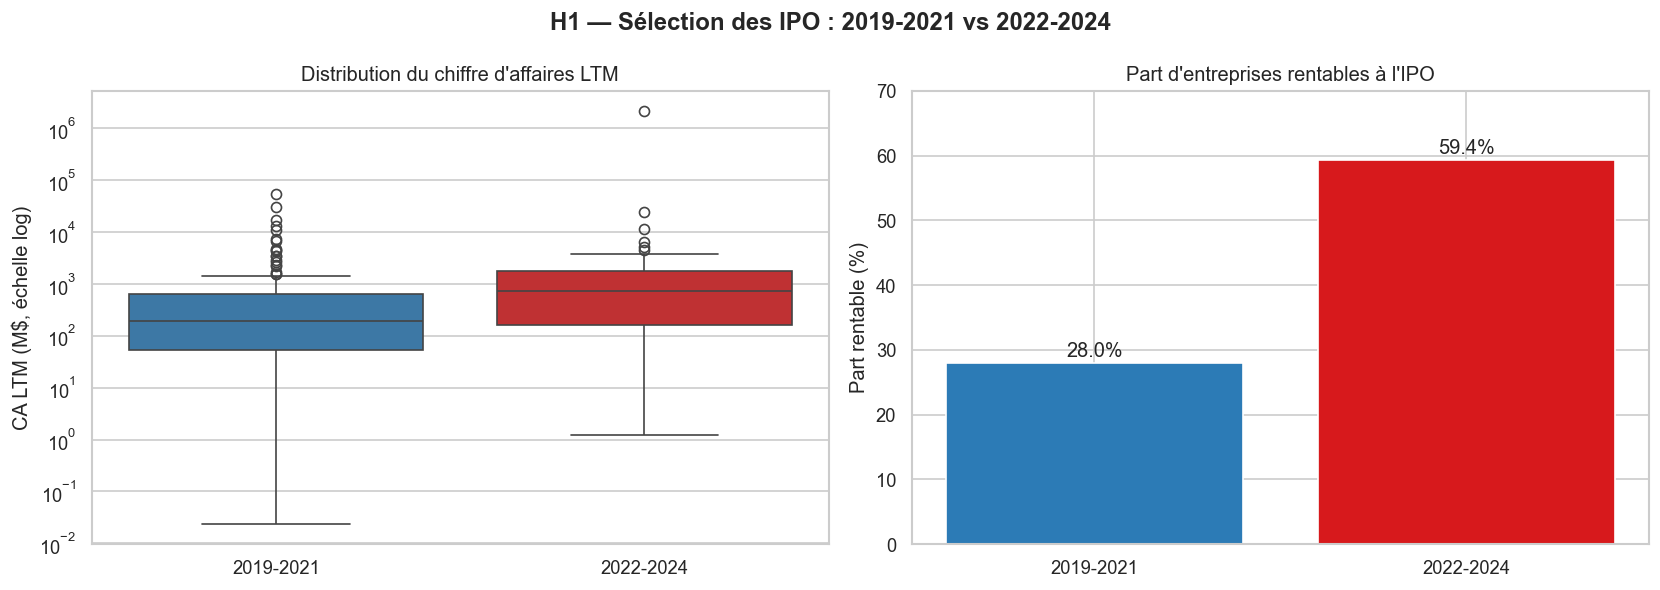

,Indicateur,2019-2021,2022-2024,Valeur test
0,CA médian,171.7255,610.6415,
1,IC95 CA médian,[134.93 ; 249.82],[218.10 ; 1032.00],
2,Part rentable,0.279503,0.59375,
3,Test Mann-Whitney CA,,,0.011498
4,Z-test proportion rentable,,,0.000005


Lecture : H1 est soutenue si le CA médian et la part rentable sont plus élevés en 2022-2024, avec p-value < 5%.


In [270]:
df = load_data(DATA_PATH)
df = clean_h1(df)

print("Effectifs par cohorte :")
display(df["cohort"].value_counts().reindex(["2019-2021", "2022-2024"]).to_frame("N"))

summary = make_summary_h1(df)
display(summary.style.format({
    "CA médian LTM (M$)": "{:.2f}",
    "CA Q1 (M$)": "{:.2f}",
    "CA Q3 (M$)": "{:.2f}",
    "Part rentable": "{:.2%}",
}))

plot_h1(df)

test_h1 = run_tests_h1(df)
display(test_h1)

print("Lecture : H1 est soutenue si le CA médian et la part rentable sont plus élevés en 2022-2024, avec p-value < 5%.")


## Conclusion courte pour l’oral

Pour H1, on compare le profil des entreprises introduites en bourse entre 2019-2021 et 2022-2024.  
Les variables centrales sont le chiffre d'affaires LTM et la rentabilité nette.  
La méthode repose sur une comparaison descriptive, un boxplot en échelle log, un barplot de rentabilité, un test de Mann-Whitney et un test de proportion.  
La limite principale est que les données de rentabilité et de revenu peuvent être incomplètes selon les IPO.

---

# Bloc H2


# H2 — Analyse simplifiée de l'underpricing

## 1. Objectif de l'hypothèse

On vérifie si le rendement du premier jour est plus faible en période de taux élevés.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [271]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [272]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [273]:
def load_data(path):
    """Charge un fichier CSV ou Excel."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Remplace DATA_PATH au début du notebook par le vrai fichier CSV/XLSX."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path)


def require_columns(df, columns):
    """Vérifie que les colonnes nécessaires existent."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")


def add_cohort(df, year_col="year", high_label="2022-2024"):
    """Ajoute la cohorte 2019-2021 vs 2022-2024."""
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].between(2019, 2024)].copy()
    df["cohort"] = np.where(df[year_col].between(2019, 2021), "2019-2021", high_label)
    return df


def apply_size_filter(df):
    """Applique le filtre taille >= 50 M$ si la colonne existe."""
    df = df.copy()
    if "ipo_size_m" in df.columns:
        df["ipo_size_m"] = pd.to_numeric(df["ipo_size_m"], errors="coerce")
        df = df[(df["ipo_size_m"].isna()) | (df["ipo_size_m"] >= 50)].copy()
    return df


def bootstrap_ci(x, stat_fn=np.mean, n_boot=5000, alpha=0.05, seed=42):
    """Intervalle de confiance bootstrap percentile."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    try:
        boot = stat_fn(x[idx], axis=1)
    except TypeError:
        boot = np.array([stat_fn(sample) for sample in x[idx]])
    return stat_fn(x), np.quantile(boot, alpha / 2), np.quantile(boot, 1 - alpha / 2)


def format_percent_table(df, columns):
    """Affiche des colonnes en pourcentage."""
    return df.style.format({col: "{:.2%}" for col in columns if col in df.columns})


import statsmodels.formula.api as smf

def load_optional_fred(path):
    """Charge FRED si le fichier est disponible."""
    path = Path(path)
    if path.exists():
        return load_data(path)
    print("Fichier FRED non trouvé : le graphique annuel utilisera la colonne fed_rate du dataset si elle existe.")
    return None


def clean_h2(df):
    require_columns(df, ["year", "underpricing"])
    df = add_cohort(df)
    df = apply_size_filter(df)
    df["underpricing"] = pd.to_numeric(df["underpricing"], errors="coerce")
    if "fed_rate" in df.columns:
        df["fed_rate"] = pd.to_numeric(df["fed_rate"], errors="coerce")
    if "log_size" not in df.columns and "ipo_size_m" in df.columns:
        df["log_size"] = np.log(df["ipo_size_m"].where(df["ipo_size_m"] > 0))
    return df.dropna(subset=["underpricing", "cohort"]).copy()


def validate_h2_sample(df):
    checks = []
    if "ipo_size_m" in df.columns:
        checks.append(["ipo_size_m >= 50 M$", df["ipo_size_m"].min(), (df["ipo_size_m"] >= 50).mean()])
    if "open_px" in df.columns:
        checks.append(["open_px > 5 $", df["open_px"].min(), (df["open_px"] > 5).mean()])
    if not checks:
        return pd.DataFrame({"Message": ["Colonnes ipo_size_m/open_px absentes : critères quantitatifs non vérifiables ici."]})
    return pd.DataFrame(checks, columns=["Critère", "Minimum observé", "% conforme"])


def make_summary_h2(df):
    return (df.groupby("cohort")["underpricing"]
              .agg(N="count", Moyenne="mean", Médiane="median", Ecart_type="std", Q1=lambda x: x.quantile(.25), Q3=lambda x: x.quantile(.75))
              .reindex(["2019-2021", "2022-2024"])
              .reset_index())


def plot_h2_distributions(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, cohort in zip(axes, ["2019-2021", "2022-2024"]):
        x = df.loc[df["cohort"] == cohort, "underpricing"].dropna()
        sns.histplot(x, bins=35, kde=True, color=COLORS[cohort], alpha=0.65, ax=ax)
        ax.axvline(x.mean(), color="black", linestyle="--", label=f"Moyenne = {x.mean():.2%}")
        ax.axvline(x.median(), color="gray", linestyle=":", label=f"Médiane = {x.median():.2%}")
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
        ax.set_xlim(-0.5, 0.8)
        ax.set_title(cohort)
        ax.set_xlabel("Underpricing J0")
        ax.legend()
    fig.suptitle("Distribution de l'underpricing — taux bas vs taux élevés", fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_h2_boxplot(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="cohort", y="underpricing",
                order=["2019-2021", "2022-2024"],
                palette=[COLORS["2019-2021"], COLORS["2022-2024"]])
    plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.ylim(-0.55, 1.0)
    plt.title("Comparaison de l'underpricing entre cohortes")
    plt.xlabel("")
    plt.ylabel("Underpricing au premier jour")
    plt.tight_layout()
    plt.show()


def plot_h2_by_year(df):
    if "fed_rate" not in df.columns:
        print("Colonne fed_rate absente : graphique annuel limité à l'underpricing.")
    yearly = df.groupby("year").agg(
        underpricing_moyen=("underpricing", "mean"),
        underpricing_median=("underpricing", "median"),
        fed_rate=("fed_rate", "first") if "fed_rate" in df.columns else ("underpricing", "count"),
        n=("underpricing", "count")
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(11, 5))
    colors = [COLORS["2019-2021"] if y <= 2021 else COLORS["2022-2024"] for y in yearly["year"]]
    ax1.bar(yearly["year"], yearly["underpricing_moyen"], color=colors, alpha=0.75)
    ax1.plot(yearly["year"], yearly["underpricing_median"], color="orange", marker="D", linestyle="--", label="Médiane")
    ax1.axvline(2021.5, color="purple", linestyle=":", alpha=0.7)
    ax1.axhline(0, color="black", linewidth=0.6)
    ax1.set_ylabel("Underpricing")
    ax1.set_xlabel("Année")

    if "fed_rate" in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(yearly["year"], yearly["fed_rate"], color="#2C3E50", marker="o", linewidth=2, label="Taux Fed")
        ax2.set_ylabel("Taux Fed (%)")

    ax1.set_title("Underpricing moyen et taux Fed par année")
    plt.tight_layout()
    plt.show()


def run_tests_h2(df):
    low = df.loc[df["cohort"] == "2019-2021", "underpricing"].dropna()
    high = df.loc[df["cohort"] == "2022-2024", "underpricing"].dropna()
    u_stat, p_mw = stats.mannwhitneyu(low, high, alternative="greater")
    t_stat, p_welch = stats.ttest_ind(low, high, equal_var=False, nan_policy="omit")
    robust = np.nan
    low_no_2021 = df.loc[(df["cohort"] == "2019-2021") & (df["year"] != 2021), "underpricing"].dropna()
    if len(low_no_2021) and len(high):
        _, robust = stats.mannwhitneyu(low_no_2021, high, alternative="greater")
    return pd.DataFrame({
        "Test": ["Mann-Whitney unilatéral", "Welch bilatéral", "Mann-Whitney sans 2021"],
        "Hypothèse": ["2019-2021 > 2022-2024", "moyennes différentes", "robustesse sans euphorie 2021"],
        "Statistique": [u_stat, t_stat, np.nan],
        "p-value": [p_mw, p_welch, robust],
        "Significatif 5%": [p_mw < ALPHA, p_welch < ALPHA, robust < ALPHA if np.isfinite(robust) else False],
    })


def run_ols_h2(df):
    vars_needed = ["underpricing", "fed_rate", "log_size", "pe_backed", "sector"]
    if not all(v in df.columns for v in vars_needed):
        print("OLS non exécutée : colonnes nécessaires absentes :", [v for v in vars_needed if v not in df.columns])
        return None
    work = df[vars_needed].dropna().copy()
    if len(work) < 10:
        print("OLS non exécutée : trop peu d'observations après suppression des NaN.")
        return None
    model = smf.ols("underpricing ~ fed_rate + log_size + pe_backed + C(sector)", data=work).fit(cov_type="HC3")
    table = model.summary2().tables[1].loc[[i for i in ["Intercept", "fed_rate", "log_size", "pe_backed"] if i in model.params.index]]
    display(table)

    coef = table["Coef."]
    ci_low = table["[0.025"]
    ci_high = table["0.975]"]
    plt.figure(figsize=(9, 4))
    plt.barh(coef.index, coef.values, xerr=[coef - ci_low, ci_high - coef])
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Coefficients OLS principaux avec IC 95% robustes HC3")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()
    return model


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Vérification rapide de l'échantillon :


,Critère,Minimum observé,% conforme
0,ipo_size_m >= 50 M$,50.355369,1.000000
1,open_px > 5 $,4.550000,0.995556


Statistiques descriptives :


,cohort,N,Moyenne,Médiane,Ecart_type,Q1,Q3
0,2019-2021,161,29.00%,26.43%,28.87%,9.13%,50.65%
1,2022-2024,64,14.58%,9.53%,26.71%,-2.02%,27.85%


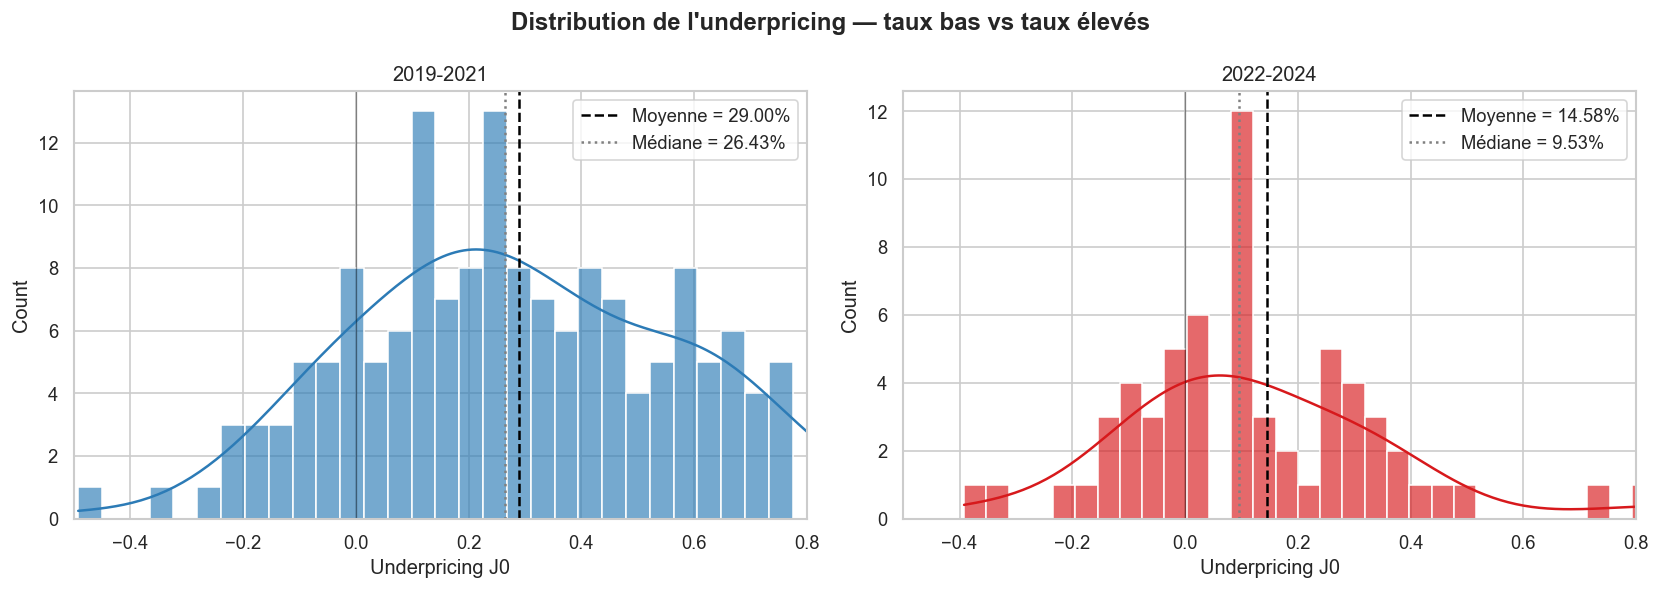

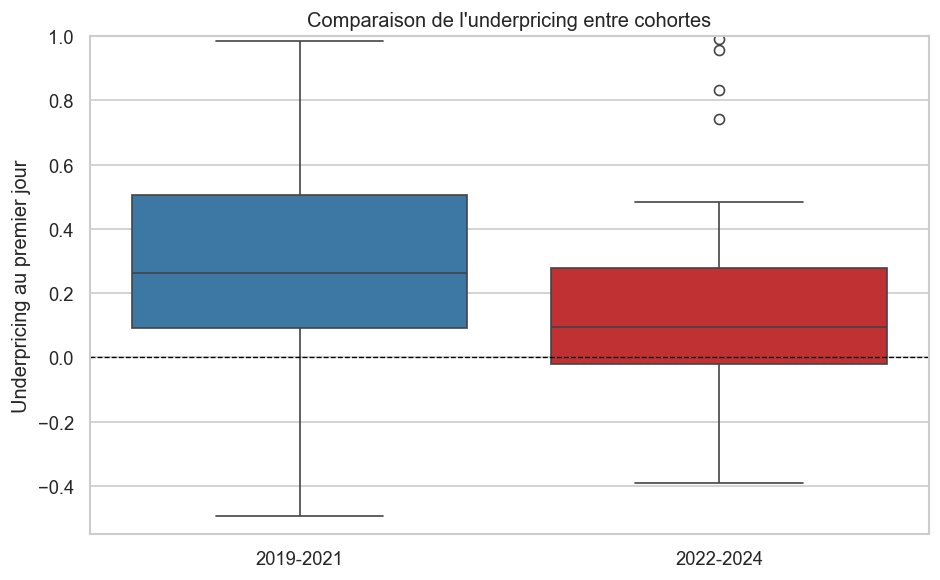

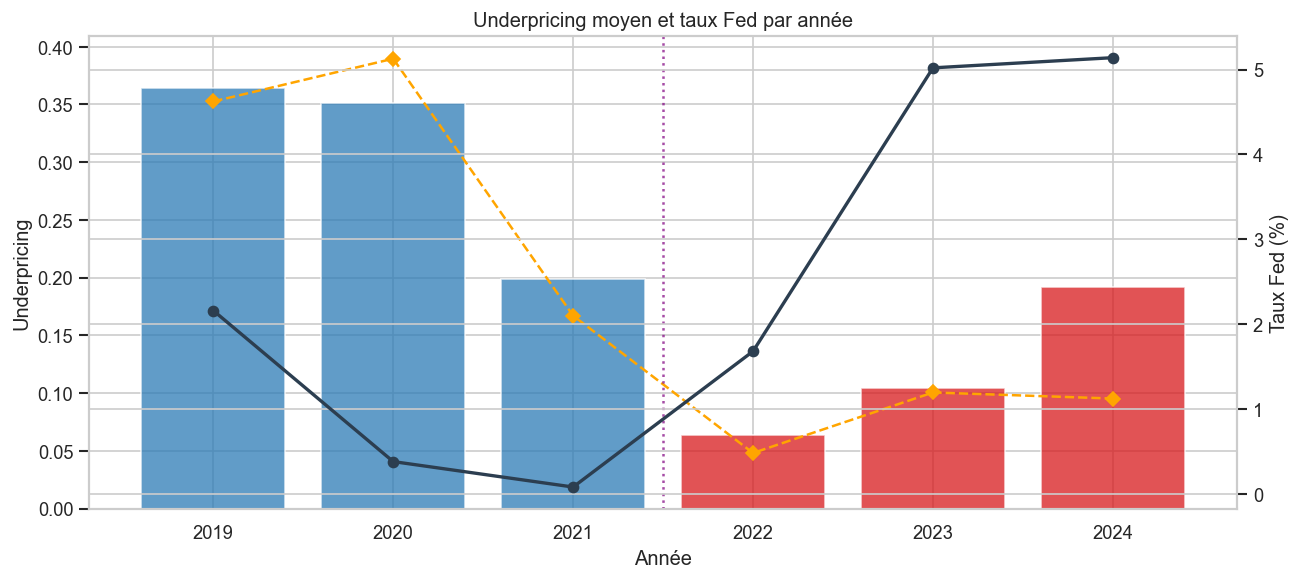

Tests statistiques principaux :


,Test,Hypothèse,Statistique,p-value,Significatif 5%
0,Mann-Whitney unilatéral,2019-2021 > 2022-2024,6784.0000,0.0001,True
1,Welch bilatéral,moyennes différentes,3.5701,0.0005,True
2,Mann-Whitney sans 2021,robustesse sans euphorie 2021,nan,0.0000,True


Régression OLS si les colonnes de contrôle existent :


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,0.022126,0.150231,0.147282,0.882909,-0.272320,0.316573
fed_rate,-0.011364,0.009794,-1.160210,0.245963,-0.030560,0.007833
log_size,0.058699,0.020344,2.885317,0.003910,0.018826,0.098573
pe_backed,0.014238,0.097087,0.146649,0.883409,-0.176049,0.204524


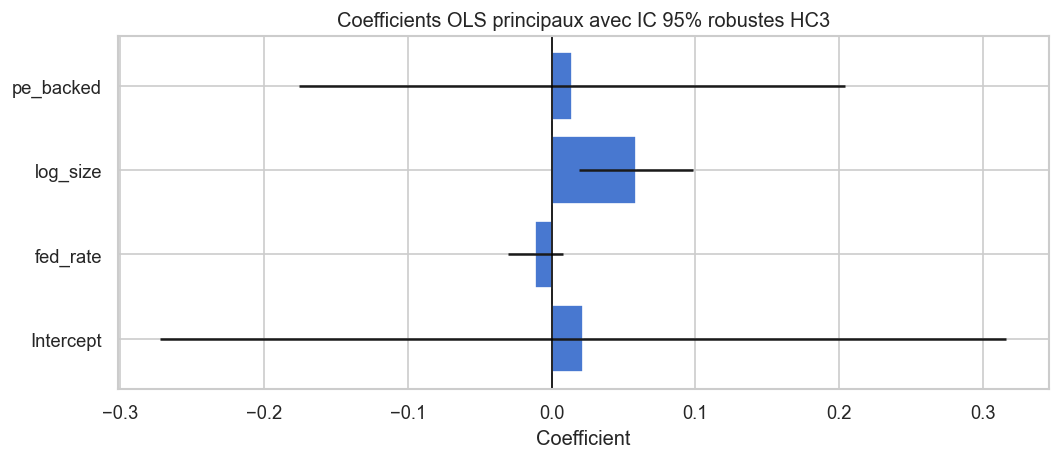

Lecture : H2 est soutenue si 2022-2024 présente un underpricing plus faible, confirmé par Mann-Whitney et par le signe négatif du coefficient fed_rate en OLS.


In [274]:
df = load_data(DATA_PATH)
fred = load_optional_fred(FRED_PATH)

df = clean_h2(df)

print("Vérification rapide de l'échantillon :")
display(validate_h2_sample(df))

print("Statistiques descriptives :")
summary = make_summary_h2(df)
display(summary.style.format({
    "Moyenne": "{:.2%}",
    "Médiane": "{:.2%}",
    "Ecart_type": "{:.2%}",
    "Q1": "{:.2%}",
    "Q3": "{:.2%}",
}))

plot_h2_distributions(df)
plot_h2_boxplot(df)
plot_h2_by_year(df)

print("Tests statistiques principaux :")
tests = run_tests_h2(df)
display(tests.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

print("Régression OLS si les colonnes de contrôle existent :")
ols_model = run_ols_h2(df)

print("Lecture : H2 est soutenue si 2022-2024 présente un underpricing plus faible, confirmé par Mann-Whitney et par le signe négatif du coefficient fed_rate en OLS.")


## Conclusion courte pour l’oral

Pour H2, on teste si l'underpricing est plus faible en 2022-2024 qu'en 2019-2021.  
La variable centrale est le rendement du premier jour.  
La méthode combine statistiques descriptives, histogrammes/KDE, boxplot, comparaison annuelle avec le taux Fed, Mann-Whitney, Welch, OLS et robustesse sans 2021.  
La limite principale est que le taux annuel ne sépare pas parfaitement l'effet macroéconomique des effets de cohorte, de secteur et d'euphorie de 2021.

---

# Bloc H3




# H3 — Analyse simplifiée de la performance à 30 jours

## 1. Objectif de l'hypothèse

On vérifie si les rendements à 30 jours sont plus stables en 2022-2024.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [275]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [276]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [277]:
def load_data(path):
    """Charge un fichier CSV ou Excel."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Remplace DATA_PATH au début du notebook par le vrai fichier CSV/XLSX."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path)


def require_columns(df, columns):
    """Vérifie que les colonnes nécessaires existent."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")


def add_cohort(df, year_col="year", high_label="2022-2024"):
    """Ajoute la cohorte 2019-2021 vs 2022-2024."""
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].between(2019, 2024)].copy()
    df["cohort"] = np.where(df[year_col].between(2019, 2021), "2019-2021", high_label)
    return df


def apply_size_filter(df):
    """Applique le filtre taille >= 50 M$ si la colonne existe."""
    df = df.copy()
    if "ipo_size_m" in df.columns:
        df["ipo_size_m"] = pd.to_numeric(df["ipo_size_m"], errors="coerce")
        df = df[(df["ipo_size_m"].isna()) | (df["ipo_size_m"] >= 50)].copy()
    return df


def bootstrap_ci(x, stat_fn=np.mean, n_boot=5000, alpha=0.05, seed=42):
    """Intervalle de confiance bootstrap percentile."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    try:
        boot = stat_fn(x[idx], axis=1)
    except TypeError:
        boot = np.array([stat_fn(sample) for sample in x[idx]])
    return stat_fn(x), np.quantile(boot, alpha / 2), np.quantile(boot, 1 - alpha / 2)


def format_percent_table(df, columns):
    """Affiche des colonnes en pourcentage."""
    return df.style.format({col: "{:.2%}" for col in columns if col in df.columns})


def clean_h3(df):
    require_columns(df, ["year", "ret_30d"])
    df = add_cohort(df)
    df = apply_size_filter(df)
    df["ret_30d"] = pd.to_numeric(df["ret_30d"], errors="coerce")
    return df.dropna(subset=["ret_30d"]).copy()


def make_summary_h3(df):
    return (df.groupby("cohort")["ret_30d"]
              .agg(N="count", Moyenne="mean", Médiane="median", Ecart_type="std", IQR=lambda x: x.quantile(.75)-x.quantile(.25))
              .reindex(["2019-2021", "2022-2024"])
              .reset_index())


def plot_h3(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    plot_df = df.copy()
    plot_df["ret_30d_pct"] = plot_df["ret_30d"] * 100
    sns.boxplot(data=plot_df, x="cohort", y="ret_30d_pct",
                order=["2019-2021", "2022-2024"],
                palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
                ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Distribution des rendements à 30 jours")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Rendement à 30 jours (%)")

    for cohort in ["2019-2021", "2022-2024"]:
        x = df.loc[df["cohort"] == cohort, "ret_30d"].dropna() * 100
        sns.kdeplot(x, fill=True, alpha=0.25, color=COLORS[cohort],
                    label=f"{cohort} (σ={x.std():.1f}%)", ax=axes[1])
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Distribution en densité")
    axes[1].set_xlabel("Rendement à 30 jours (%)")
    axes[1].legend()

    summary = make_summary_h3(df)
    y = summary["Ecart_type"] * 100
    axes[2].bar(summary["cohort"], y, color=[COLORS["2019-2021"], COLORS["2022-2024"]])
    axes[2].set_title("Volatilité cross-sectionnelle")
    axes[2].set_ylabel("Écart-type σ (%)")

    fig.suptitle("H3 — Stabilité des rendements à 30 jours", fontweight="bold")
    plt.tight_layout()
    plt.show()


def run_tests_h3(df):
    low = df.loc[df["cohort"] == "2019-2021", "ret_30d"].dropna()
    high = df.loc[df["cohort"] == "2022-2024", "ret_30d"].dropna()
    std_low, std_high = low.std(ddof=1), high.std(ddof=1)
    f_ratio = (std_high**2) / (std_low**2)
    p_f = stats.f.cdf(f_ratio, len(high)-1, len(low)-1)
    lev_stat, p_lev_bi = stats.levene(low, high, center="median")
    p_lev = p_lev_bi / 2 if std_high < std_low else 1 - p_lev_bi / 2
    fl_stat, p_fl_bi = stats.fligner(low, high)
    p_fl = p_fl_bi / 2 if std_high < std_low else 1 - p_fl_bi / 2
    mw_stat, p_mw = stats.mannwhitneyu(high, low, alternative="two-sided")
    return pd.DataFrame({
        "Test": ["F-test variance", "Levene", "Fligner-Killeen", "Mann-Whitney complémentaire"],
        "Hypothèse": ["σ 2022-2024 < σ 2019-2021", "variance plus faible", "variance plus faible", "distributions différentes"],
        "Statistique": [f_ratio, lev_stat, fl_stat, mw_stat],
        "p-value": [p_f, p_lev, p_fl, p_mw],
        "Significatif 5%": [p_f < ALPHA, p_lev < ALPHA, p_fl < ALPHA, p_mw < ALPHA],
    })


## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Statistiques descriptives :


,cohort,N,Moyenne,Médiane,Ecart_type,IQR
0,2019-2021,161,7.69%,1.93%,27.09%,28.43%
1,2022-2024,64,2.64%,6.27%,18.51%,21.51%


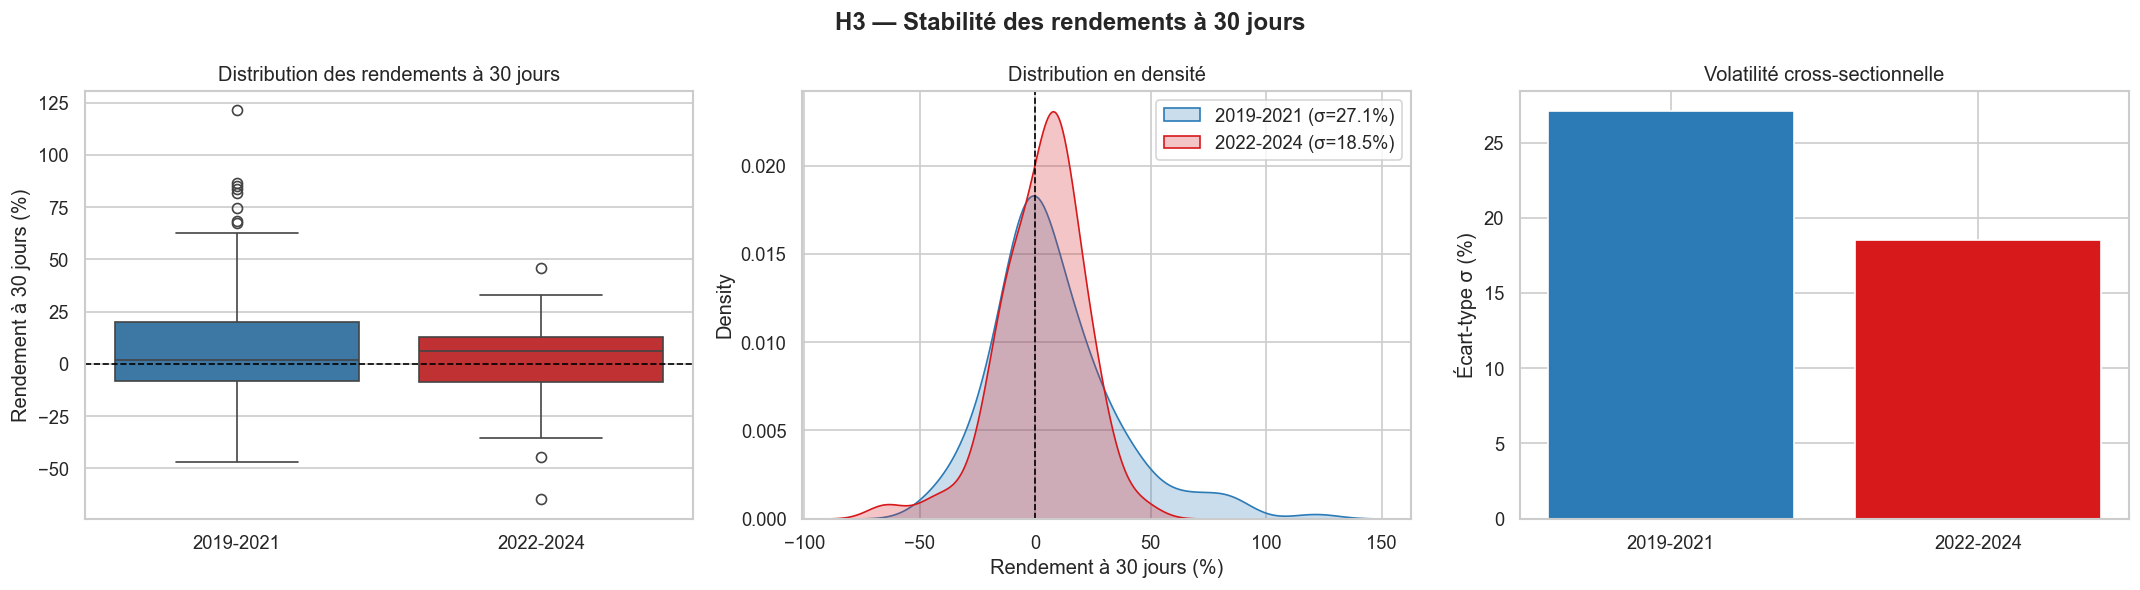

Tests sur la stabilité / dispersion :


,Test,Hypothèse,Statistique,p-value,Significatif 5%
0,F-test variance,σ 2022-2024 < σ 2019-2021,0.4668,0.0004,True
1,Levene,variance plus faible,4.4755,0.0177,True
2,Fligner-Killeen,variance plus faible,4.0082,0.0226,True
3,Mann-Whitney complémentaire,distributions différentes,5012.0000,0.7515,False


Lecture : H3 est soutenue si l'écart-type 2022-2024 est inférieur et si les tests de variance vont dans ce sens.


In [278]:
df = load_data(DATA_PATH)
df = clean_h3(df)

print("Statistiques descriptives :")
summary = make_summary_h3(df)
display(summary.style.format({
    "Moyenne": "{:.2%}",
    "Médiane": "{:.2%}",
    "Ecart_type": "{:.2%}",
    "IQR": "{:.2%}",
}))

plot_h3(df)

print("Tests sur la stabilité / dispersion :")
tests = run_tests_h3(df)
display(tests.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

print("Lecture : H3 est soutenue si l'écart-type 2022-2024 est inférieur et si les tests de variance vont dans ce sens.")


## Conclusion courte pour l’oral

Pour H3, on teste si les rendements à 30 jours sont plus stables en 2022-2024.  
La variable centrale est `ret_30d`.  
La méthode repose sur la comparaison des écarts-types, des distributions, puis sur des tests de variance comme F-test, Levene et Fligner.  
La limite principale est que la stabilité mesurée ici est une dispersion entre IPO, pas une volatilité quotidienne intra-titre.

---

# Bloc H4


# H4 — Analyse simplifiée de la performance à 12 mois

## 1. Objectif de l'hypothèse

On vérifie si la performance à 12 mois est meilleure pour les IPO récentes disposant d'un recul suffisant.

## 2. Bibliothèques utilisées

On utilise uniquement des bibliothèques classiques : pandas, numpy, matplotlib, seaborn, scipy et statsmodels si nécessaire.

In [279]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

SEED = 42
ALPHA = 0.05
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C", "2022-2023": "#D7191C"}

print("Imports OK")


Imports OK


## 3. Paramètres principaux

Remplace seulement les chemins ci-dessous par tes vrais fichiers.

In [280]:
DATA_PATH = "data/dataset.xlsx"
FRED_PATH = "data/fred_annual.xlsx"

## 4. Fonctions simples

Les fonctions suivantes gardent la logique visible : chargement, nettoyage, cohortes, tableaux, graphiques et tests.

In [281]:
def load_data(path):
    """Charge un fichier CSV ou Excel."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            "Remplace DATA_PATH au début du notebook par le vrai fichier CSV/XLSX."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    return pd.read_excel(path)


def require_columns(df, columns):
    """Vérifie que les colonnes nécessaires existent."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")


def add_cohort(df, year_col="year", high_label="2022-2024"):
    """Ajoute la cohorte 2019-2021 vs 2022-2024."""
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].between(2019, 2024)].copy()
    df["cohort"] = np.where(df[year_col].between(2019, 2021), "2019-2021", high_label)
    return df


def apply_size_filter(df):
    """Applique le filtre taille >= 50 M$ si la colonne existe."""
    df = df.copy()
    if "ipo_size_m" in df.columns:
        df["ipo_size_m"] = pd.to_numeric(df["ipo_size_m"], errors="coerce")
        df = df[(df["ipo_size_m"].isna()) | (df["ipo_size_m"] >= 50)].copy()
    return df


def bootstrap_ci(x, stat_fn=np.mean, n_boot=5000, alpha=0.05, seed=42):
    """Intervalle de confiance bootstrap percentile."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    try:
        boot = stat_fn(x[idx], axis=1)
    except TypeError:
        boot = np.array([stat_fn(sample) for sample in x[idx]])
    return stat_fn(x), np.quantile(boot, alpha / 2), np.quantile(boot, 1 - alpha / 2)


def format_percent_table(df, columns):
    """Affiche des colonnes en pourcentage."""
    return df.style.format({col: "{:.2%}" for col in columns if col in df.columns})


def clean_h4(df):
    require_columns(df, ["year", "ret_12m"])
    df = df.copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df[df["year"].between(2019, 2024)].copy()
    df["cohort_h4"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")
    df = apply_size_filter(df)
    df["ret_12m"] = pd.to_numeric(df["ret_12m"], errors="coerce")
    return df.dropna(subset=["ret_12m"]).copy()


def make_summary_h4(df):
    return (df.groupby("cohort_h4")["ret_12m"]
              .agg(N="count", Moyenne="mean", Médiane="median", Ecart_type="std", Q1=lambda x: x.quantile(.25), Q3=lambda x: x.quantile(.75))
              .reindex(["2019-2021", "2022-2024"])
              .reset_index())


def plot_h4(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df, x="cohort_h4", y="ret_12m",
                order=["2019-2021", "2022-2024"],
                palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
                ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Distribution des rendements à 12 mois")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Rendement à 12 mois")

    if df["cohort_h4"].nunique() == 2:
        sns.kdeplot(data=df, x="ret_12m", hue="cohort_h4",
                    hue_order=["2019-2021", "2022-2024"],
                    fill=True, common_norm=False,
                    palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
                    alpha=0.25, ax=axes[1])
        axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
    else:
        axes[1].text(0.5, 0.5, "Données insuffisantes pour comparer les densités", ha="center")
        axes[1].axis("off")
    axes[1].set_title("Densité des rendements à 12 mois")
    fig.suptitle("H4 — Performance à long terme", fontweight="bold")
    plt.tight_layout()
    plt.show()


def run_tests_h4(df):
    low = df.loc[df["cohort_h4"] == "2019-2021", "ret_12m"].dropna()
    high = df.loc[df["cohort_h4"] == "2022-2024", "ret_12m"].dropna()
    mean_low, mean_low_lo, mean_low_hi = bootstrap_ci(low, np.mean, seed=SEED)
    mean_high, mean_high_lo, mean_high_hi = bootstrap_ci(high, np.mean, seed=SEED+1)
    med_low, med_low_lo, med_low_hi = bootstrap_ci(low, np.median, seed=SEED+2)
    med_high, med_high_lo, med_high_hi = bootstrap_ci(high, np.median, seed=SEED+3)
    u_stat, p_mw = stats.mannwhitneyu(high, low, alternative="greater")
    t_stat, p_welch_two = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    p_welch = p_welch_two / 2 if t_stat > 0 else 1 - p_welch_two / 2
    return pd.DataFrame({
        "Indicateur": ["Moyenne", "IC95 moyenne", "Médiane", "IC95 médiane", "Mann-Whitney p-value", "Welch p-value"],
        "2019-2021": [mean_low, f"[{mean_low_lo:.4f} ; {mean_low_hi:.4f}]", med_low, f"[{med_low_lo:.4f} ; {med_low_hi:.4f}]", "", ""],
        "2022-2024": [mean_high, f"[{mean_high_lo:.4f} ; {mean_high_hi:.4f}]", med_high, f"[{med_high_lo:.4f} ; {med_high_hi:.4f}]", "", ""],
        "Valeur test": ["", "", "", "", p_mw, p_welch],
    })

## 5. Chargement et préparation des données

On charge le fichier, on garde le périmètre du livrable 2 et on crée les cohortes.

Effectifs utilisés pour H4 :


,N
cohort_h4,
2019-2021,161
2022-2024,64


,cohort_h4,N,Moyenne,Médiane,Ecart_type,Q1,Q3
0,2019-2021,161,-0.18%,-24.13%,88.66%,-55.09%,24.57%
1,2022-2024,64,20.20%,4.43%,65.74%,-26.47%,67.61%


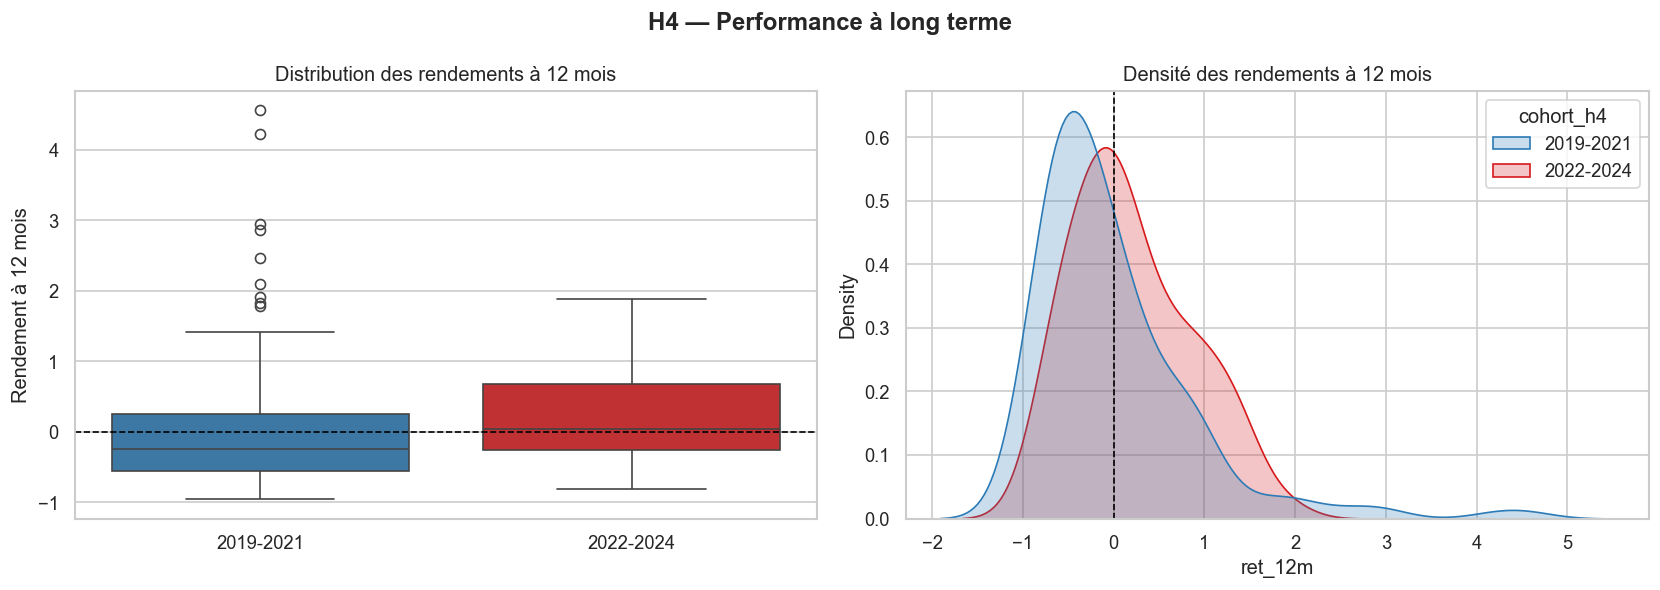

Tests et intervalles de confiance :


,Indicateur,2019-2021,2022-2024,Valeur test
0,Moyenne,-0.001824,0.201956,
1,IC95 moyenne,[-0.1372 ; 0.1436],[0.0448 ; 0.3641],
2,Médiane,-0.241266,0.044259,
3,IC95 médiane,[-0.3667 ; -0.1021],[-0.0918 ; 0.2787],
4,Mann-Whitney p-value,,,0.000954
5,Welch p-value,,,0.030364


Lecture : H4 est soutenue si les rendements à 12 mois de 2022-2024 sont supérieurs et si Mann-Whitney est significatif.


In [282]:
df = load_data(DATA_PATH)
df = clean_h4(df)


print("Effectifs utilisés pour H4 :")
display(df["cohort_h4"].value_counts().reindex(["2019-2021", "2022-2024"]).to_frame("N"))

summary = make_summary_h4(df)
display(summary.style.format({
    "Moyenne": "{:.2%}",
    "Médiane": "{:.2%}",
    "Ecart_type": "{:.2%}",
    "Q1": "{:.2%}",
    "Q3": "{:.2%}",
}))

plot_h4(df)

print("Tests et intervalles de confiance :")
tests = run_tests_h4(df)
display(tests)

print("Lecture : H4 est soutenue si les rendements à 12 mois de 2022-2024 sont supérieurs et si Mann-Whitney est significatif.")

In [283]:
df

,ticker,year,open_px,close_px,underpricing,ret_30d,ipo_size_m,fed_rate,sic,sector,...,profitable,ret_12m_flag,ipo_date,OfferPrice,Size_Million,Date,FilingUrl,ret_12m,ret_12m.1,cohort_h4
0,PINS,2019,23.750000,24.400000,0.284211,0.000000,2068.850625,2.16,7370.0,Tech,...,0.0,ok,1970-01-01 01:00:43.573,19.0,1425.000000,2019-04-18T17:22:46-04:00,https://www.sec.gov/Archives/edgar/data/150629...,-0.284836,-0.284836,2019-2021
1,REAL,2019,28.000000,28.900000,0.445000,-0.381315,550.765600,2.16,5900.0,Consumer,...,0.0,ok,1970-01-01 01:00:43.644,20.0,300.000000,2019-06-28T06:07:10-04:00,https://www.sec.gov/Archives/edgar/data/157322...,-0.536332,-0.536332,2019-2021
2,PGNY,2019,13.500000,15.940000,0.226154,0.744668,67.140900,2.16,8090.0,Healthcare,...,0.0,ok,1970-01-01 01:00:43.763,13.0,130.000000,2019-10-25T16:44:36-04:00,https://www.sec.gov/Archives/edgar/data/155130...,0.753451,0.753451,2019-2021
4,TW,2019,33.162919,34.663288,0.283825,0.208880,1083.160644,2.16,6200.0,Finance,...,1.0,ok,1970-01-01 01:00:43.559,27.0,1080.000000,2019-04-05T17:24:29-04:00,https://www.sec.gov/Archives/edgar/data/175873...,0.285032,0.285032,2019-2021
5,PSNL,2019,23.600000,28.490000,0.675882,-0.445770,147.962562,2.16,8071.0,Healthcare,...,0.0,ok,1970-01-01 01:00:43.636,17.0,134.665500,2019-06-20T17:16:54-04:00,https://www.sec.gov/Archives/edgar/data/152775...,-0.574588,-0.574588,2019-2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,KLC,2024,27.000000,26.129999,0.088750,-0.127440,253.943100,5.14,8351.0,Other,...,0.0,ok,1970-01-01 01:00:45.574,24.0,576.000000,2024-10-09T16:15:45-04:00,https://www.sec.gov/Archives/edgar/data/187352...,-0.782243,-0.782243,2022-2024
342,RDDT,2024,47.000000,50.439999,0.483529,-0.075337,2289.158500,5.14,7374.0,Tech,...,1.0,ok,1970-01-01 01:00:45.372,34.0,748.000000,2024-03-21T09:03:42-04:00,https://www.sec.gov/Archives/edgar/data/171344...,1.477002,1.477002,2022-2024
345,LOAR,2024,45.000000,48.799999,0.742857,0.210246,313.429500,5.14,3728.0,Industrials,...,1.0,ok,1970-01-01 01:00:45.407,28.0,308.000000,2024-04-26T16:18:56-04:00,https://www.sec.gov/Archives/edgar/data/200017...,0.959016,0.959016,2022-2024
346,MRX,2024,18.907046,18.412554,-0.030918,0.053712,137.437208,5.14,6200.0,Finance,...,1.0,ok,1970-01-01 01:00:45.407,19.0,292.307685,2024-04-25T19:31:09-04:00,https://www.sec.gov/Archives/edgar/data/199746...,1.347062,1.347062,2022-2024


## Conclusion courte pour l'oral

Pour H4, on compare la performance à 12 mois de 2019-2021 à celle de 2022-2024.  
Les IPO de 2024 sont exclues, car elles n'ont pas toutes assez de recul historique.  
La méthode combine comparaison descriptive, boxplot, densité, bootstrap et test de Mann-Whitney unilatéral.  
La limite principale est la taille réduite de la cohorte récente avec 12 mois de recul.